# Song genre classification with Ollama
## Assignment 3, part 2: Zero-shot and Few-shot prompting

In [3]:
!pip install -q ollama

In [17]:
import re
import random
import pandas as pd
import ollama

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Load the training and test datasets
train_df = pd.read_csv("genreLyrics_train.csv", sep="\t", index_col=0)
test_df = pd.read_csv("genreLyrics_test.csv", sep="\t", index_col=0)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (5000, 2)
Test shape: (1500, 2)


,genre,lyrics
263935,Rock,"I knew a man, called him Sandy Cane\nFew folks..."
64235,Country,(Gary Harrison - Kent Robbins - Gene Miller)\n...
197695,Rock,You think its right when you see my reaction\n...
274428,Electronic,"Darkness, you are gentle when you kiss me\nYou..."
116870,Rock,"Cold fire, you've got everything but cold fire..."


In [19]:
test_df.head()

,genre,lyrics
253513,Hip-Hop,"State Property Music\nuh, holla, uh...... yeah..."
218012,Country,Well I really had a ball last night\nI held al...
91614,Rock,[lyrics:Stefan Ruiters]\nsolar child is burnin...
320535,Electronic,La milonga.\nLadies and gentlemen\nA man.\nMil...
248213,Pop,Anybody ever tell you that you're not whole\nA...


In [20]:
# Check how many songs exist per genre
print("Train genres:")
print(train_df["genre"].value_counts())

print("\nTest genres:")
print(test_df["genre"].value_counts())

Train genres:
genre
Rock          2213
Pop            843
Hip-Hop        518
Metal          498
Country        302
Jazz           166
Electronic     156
Other          111
Indie           74
R&B             67
Folk            52
Name: count, dtype: int64

Test genres:
genre
Rock          655
Pop           255
Hip-Hop       163
Metal         151
Country        89
Electronic     57
Jazz           43
Other          31
R&B            23
Folk           17
Indie          16
Name: count, dtype: int64


In [21]:
# Create a list of all possible genres
genres = sorted(train_df["genre"].unique())

print(genres)

['Country', 'Electronic', 'Folk', 'Hip-Hop', 'Indie', 'Jazz', 'Metal', 'Other', 'Pop', 'R&B', 'Rock']


In [22]:
# For reproducibility
random_state = 42

# Sample roughly 25% per genre, with a minimum of 10 songs per genre where possible
sample_fraction = 0.25

test_sample = (
    test_df.groupby("genre", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), max(10, int(round(len(x) * sample_fraction)))),
        random_state=random_state
    ))
    .copy()
)

# Reset index
test_sample = test_sample.reset_index(drop=True)

print("Sample shape:", test_sample.shape)
print(test_sample["genre"].value_counts())

Sample shape: (394, 2)
genre
Rock          164
Pop            64
Hip-Hop        41
Metal          38
Country        22
Electronic     14
Jazz           11
Folk           10
Indie          10
Other          10
R&B            10
Name: count, dtype: int64


C:\Users\maart\AppData\Local\Temp\ipykernel_8164\1221910265.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [23]:
# Few-shot examples: 2 examples per genre from training data

few_shot_size_per_genre = 2

few_shot_examples = (
    train_df.groupby("genre", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), few_shot_size_per_genre),
                              random_state=random_state))
    .copy()
)

few_shot_examples = few_shot_examples.reset_index(drop=True)

print("Few-shot examples shape:", few_shot_examples.shape)

# Inspect example lyrics and genres
few_shot_examples[["genre","lyrics"]].head()

Few-shot examples shape: (22, 2)


C:\Users\maart\AppData\Local\Temp\ipykernel_8164\1552777633.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), few_shot_size_per_genre),


,genre,lyrics
0,Country,"Take me back to Tulsa, I'm too young to marry\..."
1,Country,It must have been an awful thing that someone ...
2,Electronic,"I rap, I\nI can see electricity\nI rap, I\nI c..."
3,Electronic,"You can sleep forever, but still you will be t..."
4,Folk,Niin kauan kun ma muistan\non ollut humppaa\ns...


In [24]:
# Select Ollama model and shared settings
MODEL_NAME = "llama3.2:1b"
MAX_LYRIC_CHARS = 200

In [25]:
# Function for zero-shot prompt
def build_zero_shot_prompt(lyrics, genres, max_chars=MAX_LYRIC_CHARS):
    lyrics = str(lyrics)[:max_chars]

    # Convert genre list to readable text
    genre_list = ", ".join(genres)

    prompt = f"""
You are classifying song lyrics by genre.

Possible genres:
{genre_list}

Task:
Read the lyrics and choose exactly one genre.

Rules:
- Reply with exactly one genre label
- Do not explain your answer
- Do not output any other text
- Use only one of these labels: {genre_list}

Lyrics:
\"\"\"
{lyrics}
\"\"\"
"""
    return prompt.strip()

In [26]:
# function for extracting only the genre label
def clean_prediction(raw_output, genres):

    # Handle missing output
    if pd.isna(raw_output):
        return "UNKNOWN"

    text = str(raw_output).strip()

    # try exact match
    for genre in genres:
        if text.lower() == genre.lower():
            return genre
    # search if genre appears somewhere in text
    for genre in genres:
        pattern = r"\b" + re.escape(genre) + r"\b"
        if re.search(pattern,
                     text,
                     flags=re.IGNORECASE):
            return genre
    # no match
    return "UNKNOWN"

In [27]:
# Function to send prompt to Ollama
def get_model_prediction(prompt, model_name=MODEL_NAME):
    try:
        response = ollama.chat(
            model=model_name,
            messages=[{"role": "user", "content": prompt}]
        )
        return response["message"]["content"].strip()
    except Exception as e:
        print("Error:", e)
        return "ERROR"

In [28]:
# Function for few-shot prompt
def build_few_shot_prompt(lyrics, genres, few_shot_df, max_chars=MAX_LYRIC_CHARS):
    lyrics = str(lyrics)[:max_chars]
    genre_list = ", ".join(genres)
    examples_text = ""

    # Add 2 examples per genre
    for _, row in few_shot_df.iterrows():
        example_lyrics = str(row["lyrics"])[:max_chars]
        example_genre = row["genre"]

        examples_text += f"""
Example:

Lyrics:
\"\"\"
{example_lyrics}
\"\"\"

Genre: {example_genre}
"""

    prompt = f"""
Classify song lyrics by genre.

Possible genres:
{genre_list}

Examples:
{examples_text}

Now classify this lyric.

Rules:
- Reply with exactly one genre label
- Do not explain your answer
- Do not output any other text
- Use only one of these labels: {genre_list}

Lyrics:
\"\"\"
{lyrics}
\"\"\"
"""

    return prompt.strip()

In [29]:
# Run zero-shot predictions

# Store predictions
zero_shot_raw = []

# Loop over test sample
for i, row in enumerate(test_sample.itertuples(index=False), start=1):
    prompt = build_zero_shot_prompt(row.lyrics, genres)
    raw_output = get_model_prediction(prompt)
    zero_shot_raw.append(raw_output)

    if i % 10 == 0:
        print(f"Done {i}/{len(test_sample)}")

Done 10/394
Done 20/394
Done 30/394
Done 40/394
Done 50/394
Done 60/394
Done 70/394
Done 80/394
Done 90/394
Done 100/394
Done 110/394
Done 120/394
Done 130/394
Done 140/394
Done 150/394
Done 160/394
Done 170/394
Done 180/394
Done 190/394
Done 200/394
Done 210/394
Done 220/394
Done 230/394
Done 240/394
Done 250/394
Done 260/394
Done 270/394
Done 280/394
Done 290/394
Done 300/394
Done 310/394
Done 320/394
Done 330/394
Done 340/394
Done 350/394
Done 360/394
Done 370/394
Done 380/394
Done 390/394


In [30]:
# store zero shot results

# Store raw outputs
test_sample["zero_shot_raw"] = zero_shot_raw

# Clean outputs into valid labels
test_sample["zero_shot_pred"] = test_sample[
    "zero_shot_raw"
].apply(lambda x:
        clean_prediction(x, genres)
)

# Inspect results
test_sample[
    ["genre",
     "zero_shot_raw",
     "zero_shot_pred"]
].head(10)

,genre,zero_shot_raw,zero_shot_pred
0,Country,Country,Country
1,Country,Country,Country
2,Country,Country,Country
3,Country,Country,Country
4,Country,Folk,Folk
5,Country,Country,Country
6,Country,Country,Country
7,Country,Country,Country
8,Country,Country,Country
9,Country,Country,Country


In [31]:
# Run few-shot predictions
few_shot_raw = []

for i, row in enumerate(test_sample.itertuples(index=False), start=1):
    prompt = build_few_shot_prompt(row.lyrics, genres, few_shot_examples)
    raw_output = get_model_prediction(prompt)
    few_shot_raw.append(raw_output)

    if i % 10 == 0:
        print(f"Done {i}/{len(test_sample)}")

Done 10/394
Done 20/394
Done 30/394
Done 40/394
Done 50/394
Done 60/394
Done 70/394
Done 80/394
Done 90/394
Done 100/394
Done 110/394
Done 120/394
Done 130/394
Done 140/394
Done 150/394
Done 160/394
Done 170/394
Done 180/394
Done 190/394
Done 200/394
Done 210/394
Done 220/394
Done 230/394
Done 240/394
Done 250/394
Done 260/394
Done 270/394
Done 280/394
Done 290/394
Done 300/394
Done 310/394
Done 320/394
Done 330/394
Done 340/394
Done 350/394
Done 360/394
Done 370/394
Done 380/394
Done 390/394


In [32]:
# store few shot results
test_sample["few_shot_raw"] = few_shot_raw

test_sample["few_shot_pred"] = test_sample[
    "few_shot_raw"
].apply(lambda x:
        clean_prediction(x, genres)
)

test_sample[
    ["genre",
     "few_shot_raw",
     "few_shot_pred"]
].head(15)

,genre,few_shot_raw,few_shot_pred
0,Country,Country,Country
1,Country,Metal,Metal
2,Country,Other,Other
3,Country,Country,Country
4,Country,Country,Country
5,Country,Country,Country
6,Country,Country,Country
7,Country,Pop,Pop
8,Country,Country,Country
9,Country,Folk,Folk


## Investigate model output

In [33]:
# Print raw outputs
print("Zero-shot raw outputs:")

for x in test_sample[
    "zero_shot_raw"
].head(10):
    print(x)

Zero-shot raw outputs:
Country
Country
Country
Country
Folk
Country
Country
Country
Country
Country


In [34]:
# Count predicted labels
print("Zero-shot label counts")
print(test_sample["zero_shot_pred"].value_counts())

print("\nFew-shot label counts")
print(test_sample["few_shot_pred"].value_counts())

print("\nZero-shot UNKNOWN count:", (test_sample["zero_shot_pred"] == "UNKNOWN").sum())
print("Few-shot UNKNOWN count:", (test_sample["few_shot_pred"] == "UNKNOWN").sum())

Zero-shot label counts
zero_shot_pred
Country       355
Electronic     18
Other          13
Folk            4
Hip-Hop         4
Name: count, dtype: int64

Few-shot label counts
few_shot_pred
Country       179
Electronic     68
Other          45
Rock           28
Metal          26
Pop            21
Hip-Hop        13
Folk           12
Jazz            2
Name: count, dtype: int64

Zero-shot UNKNOWN count: 0
Few-shot UNKNOWN count: 0


In [35]:
# Inspect invalid predictions
bad_predictions = test_sample[
    test_sample["zero_shot_pred"]=="UNKNOWN"
]
bad_predictions[
    ["genre","zero_shot_raw"]
].head(10)

,genre,zero_shot_raw


## Evaluate results

In [36]:
# True labels
y_true = test_sample["genre"]

# Predictions
y_pred_zero = test_sample["zero_shot_pred"]

print("ZERO SHOT RESULTS")

print(classification_report(
    y_true,
    y_pred_zero,
    labels=genres,
    zero_division=0
))

ZERO SHOT RESULTS
              precision    recall  f1-score   support

     Country       0.06      0.95      0.11        22
  Electronic       0.00      0.00      0.00        14
        Folk       0.25      0.10      0.14        10
     Hip-Hop       0.25      0.02      0.04        41
       Indie       0.00      0.00      0.00        10
        Jazz       0.00      0.00      0.00        11
       Metal       0.00      0.00      0.00        38
       Other       0.15      0.20      0.17        10
         Pop       0.00      0.00      0.00        64
         R&B       0.00      0.00      0.00        10
        Rock       0.00      0.00      0.00       164

    accuracy                           0.06       394
   macro avg       0.06      0.12      0.04       394
weighted avg       0.04      0.06      0.02       394



In [37]:
y_pred_few = test_sample["few_shot_pred"]

print("FEW SHOT RESULTS")

print(classification_report(
    y_true,
    y_pred_few,
    labels=genres,
    zero_division=0
))

FEW SHOT RESULTS
              precision    recall  f1-score   support

     Country       0.07      0.59      0.13        22
  Electronic       0.04      0.21      0.07        14
        Folk       0.08      0.10      0.09        10
     Hip-Hop       0.15      0.05      0.07        41
       Indie       0.00      0.00      0.00        10
        Jazz       0.00      0.00      0.00        11
       Metal       0.08      0.05      0.06        38
       Other       0.04      0.20      0.07        10
         Pop       0.29      0.09      0.14        64
         R&B       0.00      0.00      0.00        10
        Rock       0.36      0.06      0.10       164

    accuracy                           0.10       394
   macro avg       0.10      0.12      0.07       394
weighted avg       0.23      0.10      0.09       394



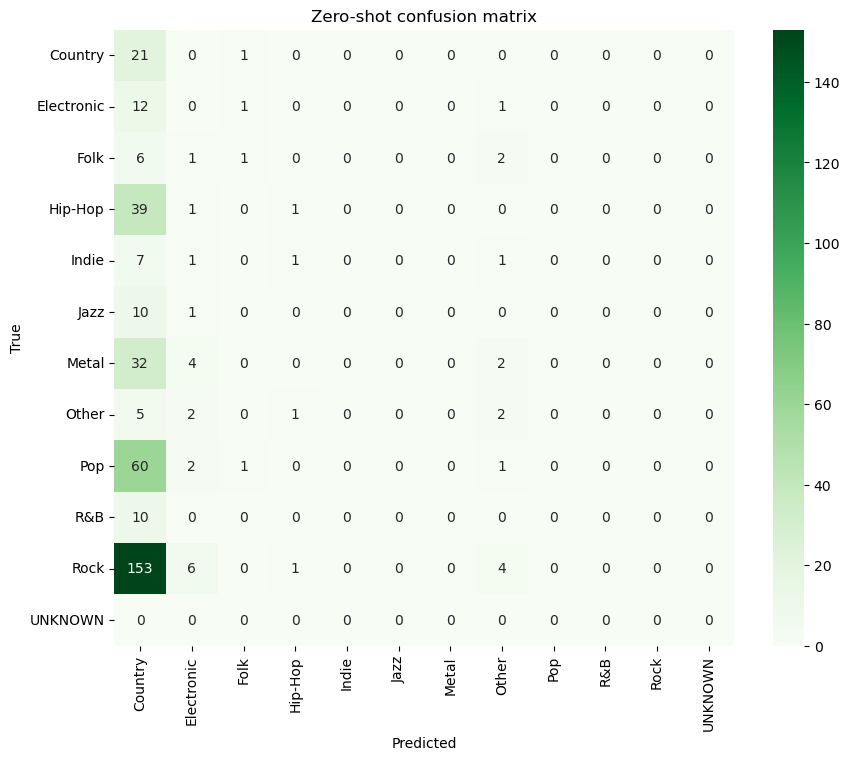

In [41]:
# Include UNKNOWN in confusion matrices so invalid outputs are visible
eval_labels = genres + ["UNKNOWN"]

# Confusion matrix for zero-shot predictions
cm_zero = confusion_matrix(
    y_true,
    y_pred_zero,
    labels=eval_labels
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_zero,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=eval_labels,
    yticklabels=eval_labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Zero-shot confusion matrix")

plt.savefig("confusion_matrix_zero_shot.png", dpi=300, bbox_inches="tight")
plt.show()

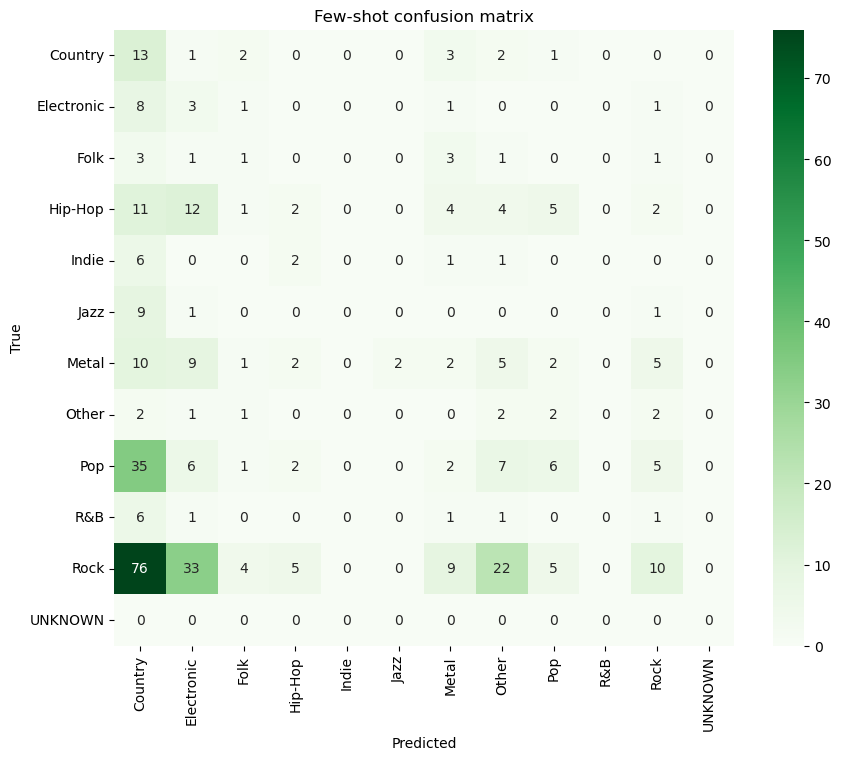

In [42]:
# Confusion matrix for few-shot predictions
cm_few = confusion_matrix(
    y_true,
    y_pred_few,
    labels=eval_labels
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_few,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=eval_labels,
    yticklabels=eval_labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Few-shot confusion matrix")

plt.savefig("confusion_matrix_few_shot.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# Save predictions to file
test_sample.to_csv("genre_predictions_sample.csv", index=False)

with open("run_settings.txt", "w", encoding="utf-8") as f:
    f.write(f"MODEL_NAME={MODEL_NAME}\n")
    f.write(f"MAX_LYRIC_CHARS={MAX_LYRIC_CHARS}\n")
    f.write(f"sample_fraction={sample_fraction}\n")
    f.write(f"random_state={random_state}\n")
    f.write(f"few_shot_size_per_genre={few_shot_size_per_genre}\n")

print("Saved: genre_predictions_sample.csv")
print("Saved: run_settings.txt")

Saved: genre_predictions_sample.csv
Saved: run_settings.txt
